In [4]:
# Import libraries
import pandas as pd

# Load the dataset
file_path = '/content/gender-classifier-DFE-791531.csv'  # Update path if needed
df = pd.read_csv(file_path, encoding='latin1')

# Display the first few rows
print(df.head())

# Check the columns
print(df.columns)

    _unit_id  _golden _unit_state  _trusted_judgments _last_judgment_at  \
0  815719226    False   finalized                   3    10/26/15 23:24   
1  815719227    False   finalized                   3    10/26/15 23:30   
2  815719228    False   finalized                   3    10/26/15 23:33   
3  815719229    False   finalized                   3    10/26/15 23:10   
4  815719230    False   finalized                   3     10/27/15 1:15   

   gender  gender:confidence profile_yn  profile_yn:confidence  \
0    male             1.0000        yes                    1.0   
1    male             1.0000        yes                    1.0   
2    male             0.6625        yes                    1.0   
3    male             1.0000        yes                    1.0   
4  female             1.0000        yes                    1.0   

          created  ...                                       profileimage  \
0    12/5/13 1:48  ...  https://pbs.twimg.com/profile_images/414342229...  

In [5]:
import re

# Filter relevant columns
df = df[['gender', 'text']]

# Drop rows with missing values
df = df.dropna()

# Extract mentions (e.g., @username) from tweets
df['mentions'] = df['text'].apply(lambda x: re.findall(r'@(\w+)', x))

# Create a list of edges (user -> mentioned user)
edges = []
for idx, row in df.iterrows():
    user_gender = row['gender']
    mentions = row['mentions']
    for mention in mentions:
        edges.append((user_gender, mention))

# Create a DataFrame for edges
edges_df = pd.DataFrame(edges, columns=['user', 'mentioned_user'])

# Display the first few edges
print(edges_df.head())

     user mentioned_user
0    male   JordanSpieth
1    male          IFTTT
2    male        PGATOUR
3   brand  BpackEngineer
4  female       _Aphmau_


Number of nodes: 7690
Number of edges: 8018


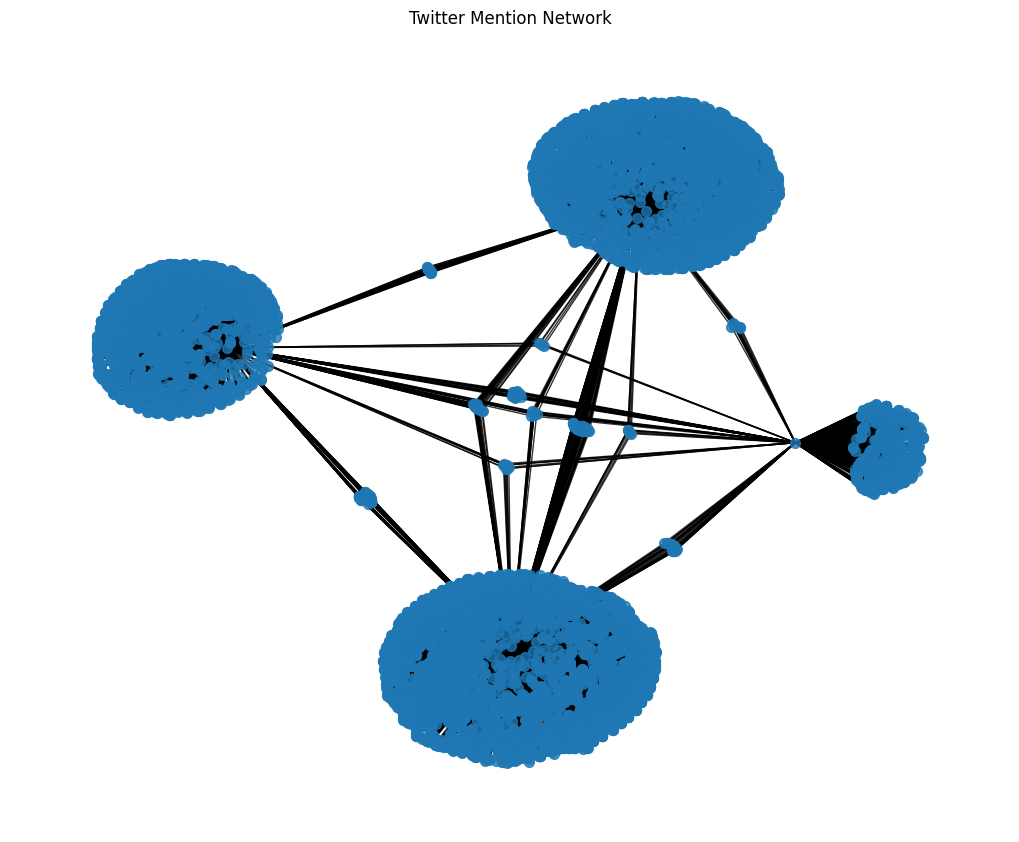

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.from_pandas_edgelist(edges_df, 'user', 'mentioned_user')

# Basic information about the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Draw the graph
plt.figure(figsize=(10, 8))
nx.draw(G, node_size=50, alpha=0.8, with_labels=False)
plt.title("Twitter Mention Network")
plt.show()

In [8]:
# Install the community library
!pip install python-louvain

# Import the library
import community as community_louvain

# Detect communities
partition = community_louvain.best_partition(G)

# Add community information to the graph
nx.set_node_attributes(G, partition, 'community')

# Display the number of communities
num_communities = len(set(partition.values()))
print("Number of communities detected:", num_communities)

Number of communities detected: 4


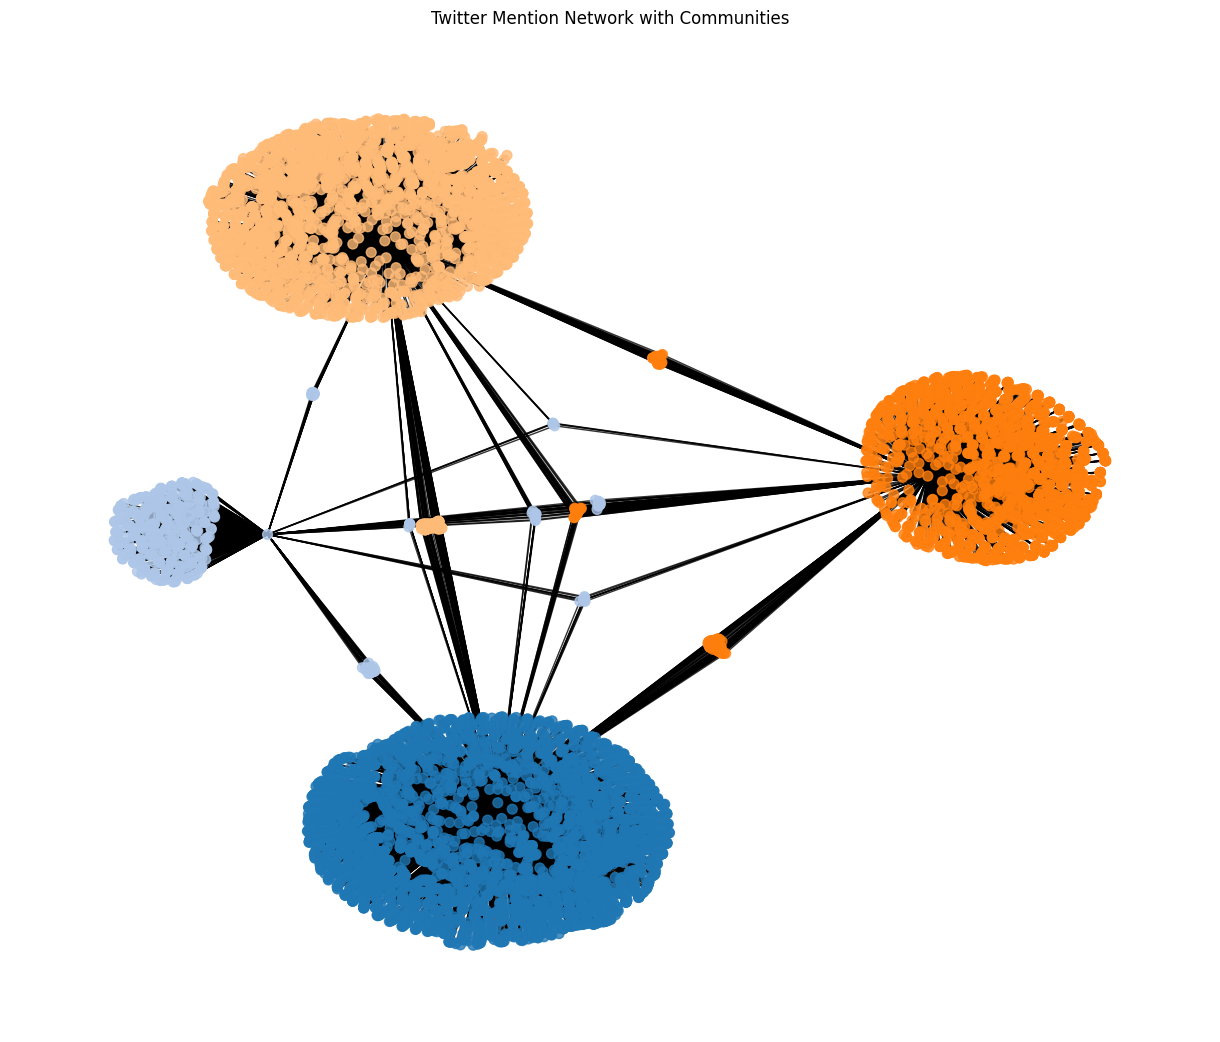

In [9]:
# Create a color map for communities
cmap = plt.cm.tab20  # Use a colormap with 20 distinct colors
colors = [cmap(partition[node] % 20) for node in G.nodes()]

# Draw the graph with community colors
plt.figure(figsize=(12, 10))
nx.draw(G, node_size=50, alpha=0.8, node_color=colors, with_labels=False)
plt.title("Twitter Mention Network with Communities")
plt.show()

Number of nodes: 14363
Number of edges: 8922
Top 10 influential users (degree centrality):
User: onedirection, Centrality: 0.009539061412059603
User: Harry_Styles, Centrality: 0.00849463862971731
User: YouTube, Centrality: 0.006405793065032726
User: justinbieber, Centrality: 0.002367358306642529
User: NBA, Centrality: 0.0011140509678317784
User: realDonaldTrump, Centrality: 0.0011140509678317784
User: 5SOS, Centrality: 0.0009051664113633199
User: lottietommo, Centrality: 0.0009051664113633199
User: sparksflylarry, Centrality: 0.0006962818548948615
User: RomanAtwood, Centrality: 0.0006962818548948615
Top 10 influential users (betweenness centrality):
User: onedirection, Centrality: 0.00032263338035041887
User: Harry_Styles, Centrality: 0.00026645471693793535
User: "Always in my heart @Harry_Styles . Yours sincerely, Louis" @onedirection Artist Of The Year #AMAs  https://t.co/HS3eXOqwx9, Centrality: 0.00019560472915450378
User: YouTube, Centrality: 9.13394183160246e-05
User: @rtpubertygo

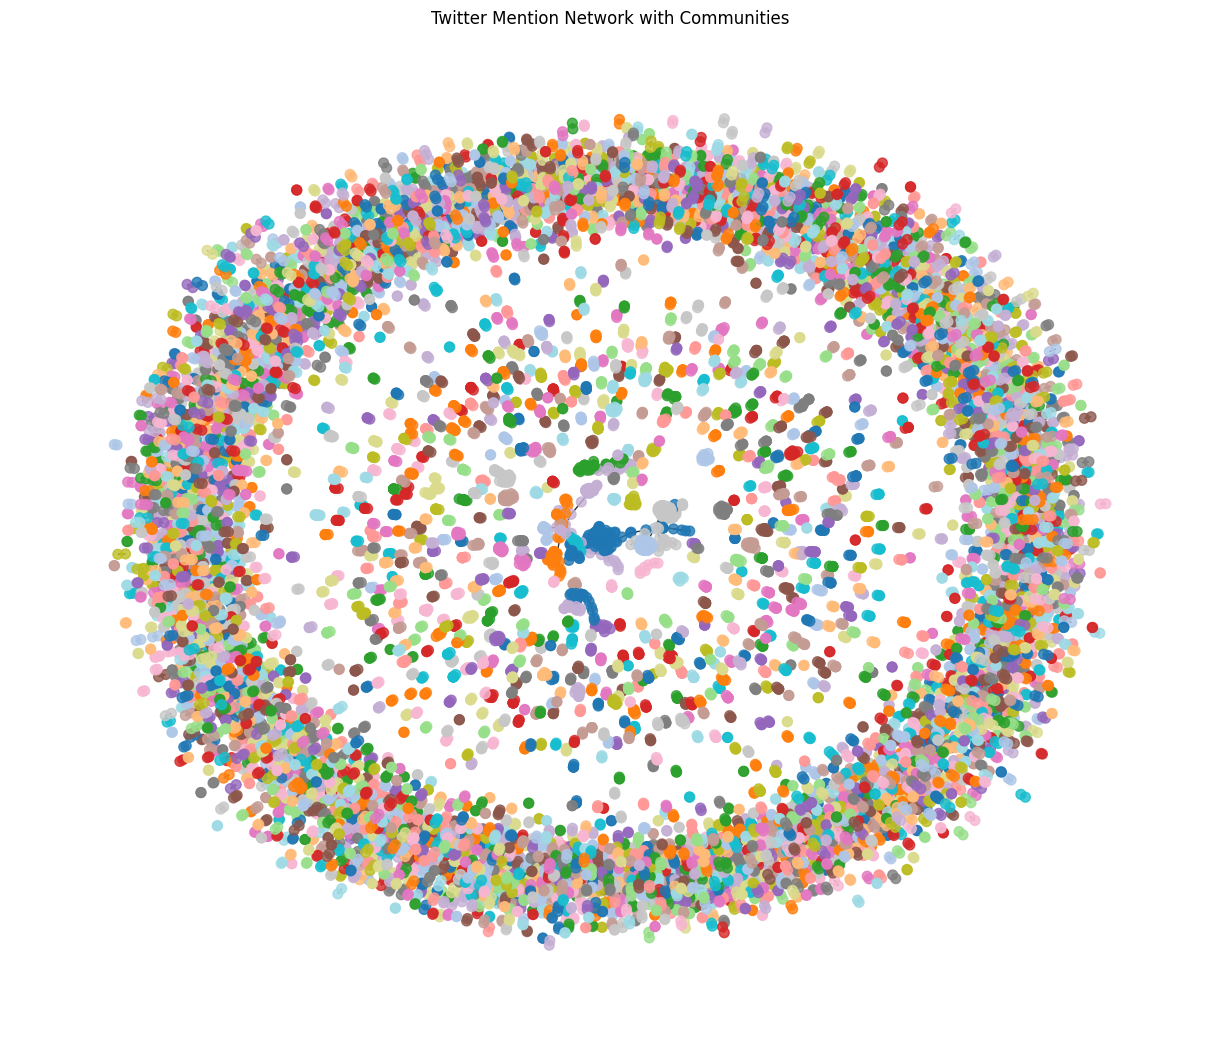

Top 10 users with the most retweets:
                                                    text  retweet_count
11848  Love this by the amazingly talented @elenamart...            330
17644  ladies and gentlemen meet your new prime minis...            153
325    #BETTERWHENIMDANCIN lyric video on @VEVO!! @Pe...             49
13438  Retweet and follow everyone who retweets my co...             36
12358  My problem is that I'll always be the one putt...             23
10805  If you want a new vine hop over there and like...             20
2600   @JonahGreen Who's excited about my contest on ...             20
13319  Rainbow hair, don't care? Show us and you coul...             19
8372   Force of nature.\n\nCR7 Savage Beauty #Mercuri...             15
980    .@TheWeeknd tops the #Hot100 (again!), but wil...             13


In [13]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import re
!pip install python-louvain
import community as community_louvain

# Step 2: Load the dataset
file_path = '/content/gender-classifier-DFE-791531.csv'  # Update path if needed
df = pd.read_csv(file_path, encoding='latin1')

# Step 3: Preprocess the data
df = df[['text', 'retweet_count']]
df = df.dropna()
df['mentions'] = df['text'].apply(lambda x: re.findall(r'@(\w+)', x))
edges = []
for idx, row in df.iterrows():
    mentions = row['mentions']
    for mention in mentions:
        edges.append((row['text'], mention))
edges_df = pd.DataFrame(edges, columns=['user', 'mentioned_user'])

# Step 4: Create the interaction network
G = nx.from_pandas_edgelist(edges_df, 'user', 'mentioned_user')
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Step 5: Identify influential users
degree_centrality = nx.degree_centrality(G)
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 10 influential users (degree centrality):")
for user, centrality in sorted_degree[:10]:
    print(f"User: {user}, Centrality: {centrality}")

betweenness_centrality = nx.betweenness_centrality(G)
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
print("Top 10 influential users (betweenness centrality):")
for user, centrality in sorted_betweenness[:10]:
    print(f"User: {user}, Centrality: {centrality}")

# Step 6: Detect communities
partition = community_louvain.best_partition(G)
nx.set_node_attributes(G, partition, 'community')
num_communities = len(set(partition.values()))
print("Number of communities detected:", num_communities)

# Step 7: Visualize the network
cmap = plt.cm.tab20
colors = [cmap(partition[node] % 20) for node in G.nodes()]
plt.figure(figsize=(12, 10))
nx.draw(G, node_size=50, alpha=0.8, node_color=colors, with_labels=False)
plt.title("Twitter Mention Network with Communities")
plt.show()

# Step 8: Analyze retweets
retweet_counts = df.groupby('text')['retweet_count'].sum().reset_index()
retweet_counts = retweet_counts.sort_values(by='retweet_count', ascending=False)
print("Top 10 users with the most retweets:")
print(retweet_counts.head(10))

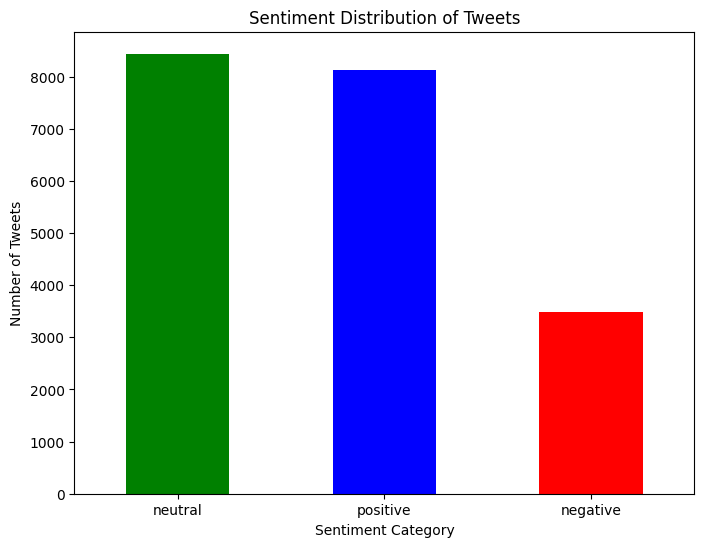

                                                text  sentiment  \
0  Robbie E Responds To Critics After Win Against...   0.800000   
1  ÛÏIt felt like they were my friends and I was...   0.000000   
2  i absolutely adore when louis starts the songs...   0.202778   
3  Hi @JordanSpieth - Looking at the url - do you...   0.166667   
4  Watching Neighbours on Sky+ catching up with t...   0.937500   

  sentiment_category  
0           positive  
1            neutral  
2           positive  
3           positive  
4           positive  


In [14]:
# Step 1: Install required libraries
!pip install textblob
!pip install pandas
!pip install matplotlib

# Step 2: Load the dataset
import pandas as pd

file_path = '/content/gender-classifier-DFE-791531.csv'  # Update path if needed
df = pd.read_csv(file_path, encoding='latin1')

# Filter relevant columns
df = df[['text']]

# Drop rows with missing values
df = df.dropna()

# Step 3: Perform sentiment analysis
from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

df['sentiment'] = df['text'].apply(get_sentiment)

# Step 4: Categorize sentiment
def categorize_sentiment(polarity):
    if polarity > 0:
        return 'positive'
    elif polarity == 0:
        return 'neutral'
    else:
        return 'negative'

df['sentiment_category'] = df['sentiment'].apply(categorize_sentiment)

# Step 5: Visualize sentiment distribution
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment_category'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Sentiment Distribution of Tweets')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()

# Display the first few rows with sentiment analysis results
print(df.head())

In [15]:
# Step 1: Install required libraries
!pip install pandas
!pip install folium
!pip install geopy

# Step 2: Load the dataset
import pandas as pd

file_path = '/content/gender-classifier-DFE-791531.csv'  # Update path if needed
df = pd.read_csv(file_path, encoding='latin1')

# Filter relevant columns
df = df[['tweet_location', 'tweet_coord']]

# Drop rows with missing values
df = df.dropna()

# Step 3: Preprocess geographic data
def extract_lat_lon(coord):
    if isinstance(coord, str):
        lat, lon = map(float, coord.strip('[]').split(','))
        return lat, lon
    return None, None

df['latitude'], df['longitude'] = zip(*df['tweet_coord'].apply(extract_lat_lon))

# Drop rows with missing latitude or longitude
df = df.dropna(subset=['latitude', 'longitude'])

# Step 4: Visualize geographic distribution
import folium

# Create a base map
m = folium.Map(location=[0, 0], zoom_start=2)

# Add markers for each tweet location
for idx, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row['tweet_location'],
        icon=folium.Icon(color='blue')
    ).add_to(m)

# Display the map
m